# Predictive Insight Engine – House Price Prediction
Complete solution for the exam.


## Part A – Conceptual Understanding
**1. Supervised Learning Algorithms**
Supervised learning algorithms learn from labeled data where both input features and target output are known. They build a model that maps inputs to outputs so that predictions can be made on new unseen data.

**2. Regression vs Classification**
Regression predicts continuous numeric values (e.g., house price). Classification predicts categorical labels (e.g., spam or not spam).

**3. Simple Linear Regression**
Simple Linear Regression models the relationship between one independent variable and a dependent variable using a straight line equation.

**4. Assumptions of Linear Regression**
- Linearity
- Independence of errors
- Homoscedasticity (constant variance)
- Normal distribution of residuals
- No strong multicollinearity

**5. Bias–Variance Trade‑Off**
Bias is error due to overly simple models. Variance is error due to models being too sensitive to training data. A good model balances both.

**6. Overfitting vs Underfitting**
Underfitting happens when a model is too simple and cannot capture patterns. Overfitting happens when a model learns noise from training data and performs poorly on new data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Part B – Dataset Understanding

In [2]:
df = pd.read_csv('RealEstate HousePrice Dataset.csv')
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB
None
            house_id    area_sqft     bedrooms    bathrooms  location_score  \
count    4200.000000  4200.000000  4200.00

**Independent variables:** area_sqft, bedrooms, bathrooms, location_score, age_years, distance_city_km, lot_size_sqft, has_garage, has_pool, renovation_years_ago

**Dependent variable:** house_price_inr


In [4]:
X = df.drop(['house_price_inr','house_id'], axis=1)
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Part C – Simple Linear Regression

In [5]:
X_simple = df[['area_sqft']]
y_simple = df['house_price_inr']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple,y_simple,test_size=0.2,random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_s,y_train_s)

y_pred_simple = model_simple.predict(X_test_s)


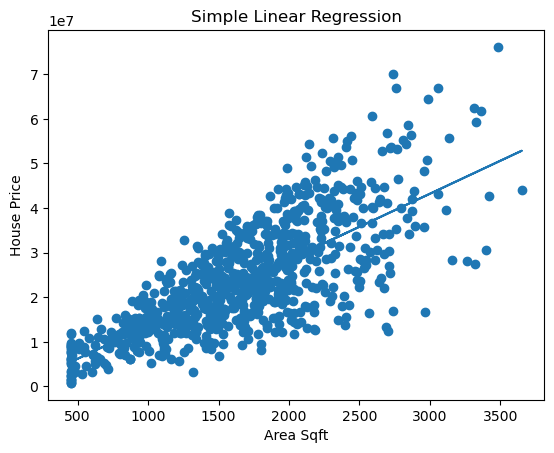

In [6]:
plt.scatter(X_test_s,y_test_s)
plt.plot(X_test_s,y_pred_simple)
plt.xlabel('Area Sqft')
plt.ylabel('House Price')
plt.title('Simple Linear Regression')
plt.show()

## Part D – Model Evaluation

In [7]:
mse = mean_squared_error(y_test_s,y_pred_simple)
mae = mean_absolute_error(y_test_s,y_pred_simple)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s,y_pred_simple)

print('MSE:',mse)
print('MAE:',mae)
print('RMSE:',rmse)
print('R2:',r2)

MSE: 66989260021849.46
MAE: 6294593.696131912
RMSE: 8184696.6969979685
R2: 0.562519958799158


Interpretation:
- Lower MSE, MAE, RMSE means better prediction accuracy.
- R² closer to 1 means better model fit.


## Part E – Multiple Linear Regression

In [8]:
model_multi = LinearRegression()
model_multi.fit(X_train,y_train)

y_pred_multi = model_multi.predict(X_test)

print('R2 Score:', r2_score(y_test,y_pred_multi))

R2 Score: 0.91776068775099


Multiple regression generally performs better because it uses more information from features.


## Part F – Polynomial Regression

In [9]:
poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_poly_train,y_train)

y_pred_poly = model_poly.predict(X_poly_test)

print('Polynomial R2:', r2_score(y_test,y_pred_poly))

Polynomial R2: 0.96643604234041


Polynomial regression can capture nonlinear relationships but may overfit if degree is too high.


## Part G – Gradient Descent (Concept)

Gradient Descent is an optimization algorithm used to minimize the loss function by iteratively adjusting model parameters.

Types:
- Batch Gradient Descent – uses full dataset
- Stochastic Gradient Descent – updates using one sample
- Mini‑Batch Gradient Descent – uses small batches


## Part H – Bias Variance Analysis

- Simple Linear Regression: High bias, low variance
- Multiple Linear Regression: Balanced
- Polynomial Regression: Low bias but higher variance


## Part I – Final Conclusion

Multiple Linear Regression generally gives the best performance because it uses multiple predictive features.
Polynomial regression can improve accuracy but risks overfitting.
Gradient descent helps efficiently optimize model parameters.
